# Archetype Crosstalk Network

Adapted from {cite:p}`Adler2023`

## Packages

In [1]:
import scanpy as sc
import liana as li

import partipy as pt
from partipy.datasets import load_fibroblast_data
from partipy.crosstalk import get_specific_genes_per_archetype, get_archetype_crosstalk, plot_weighted_network

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Data

Here we use the data from {cite:p}`muhlSinglecellAnalysisUncovers2020`.

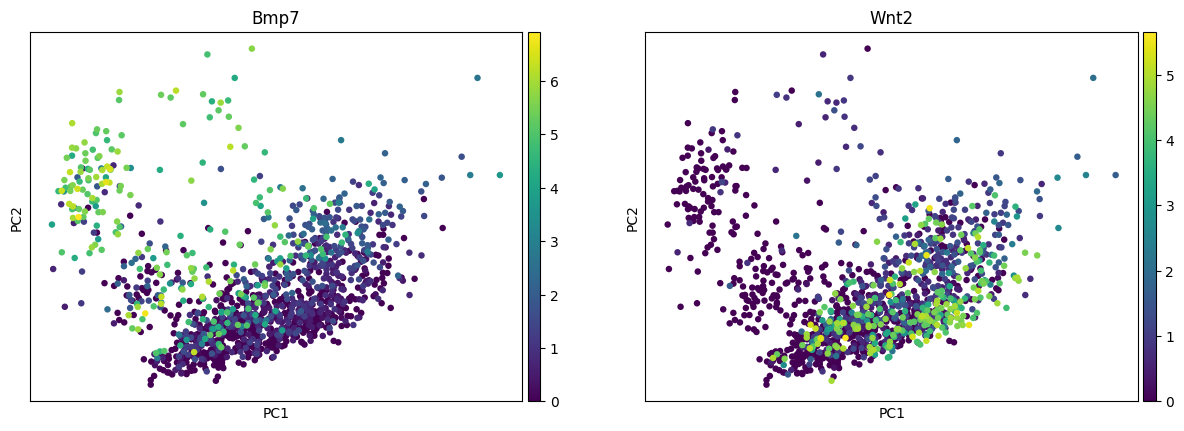

In [2]:
adata = load_fibroblast_data()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable", n_comps=50)
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True) # save this for later
sc.pl.pca_scatter(adata, color=["Bmp7", "Wnt2"])

Based on the PCA scree plot, we will be using 8 PC dimensions to fit the archetypes.

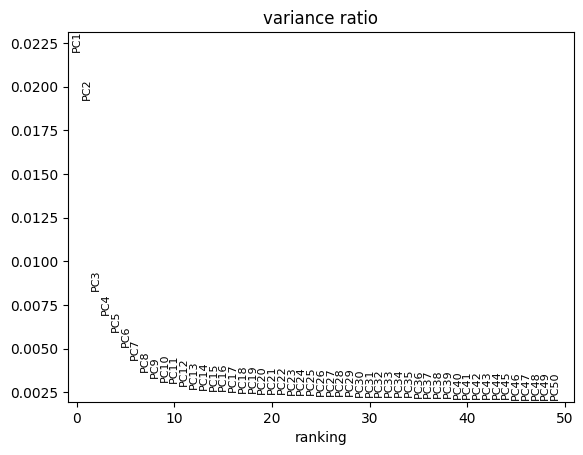

In [3]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=8)

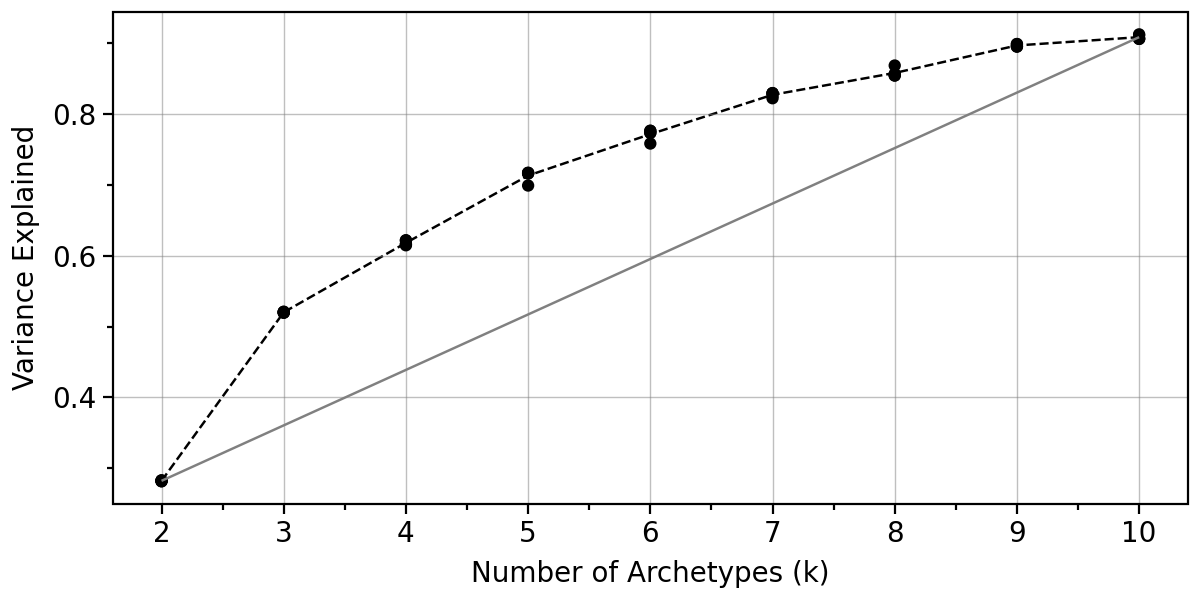

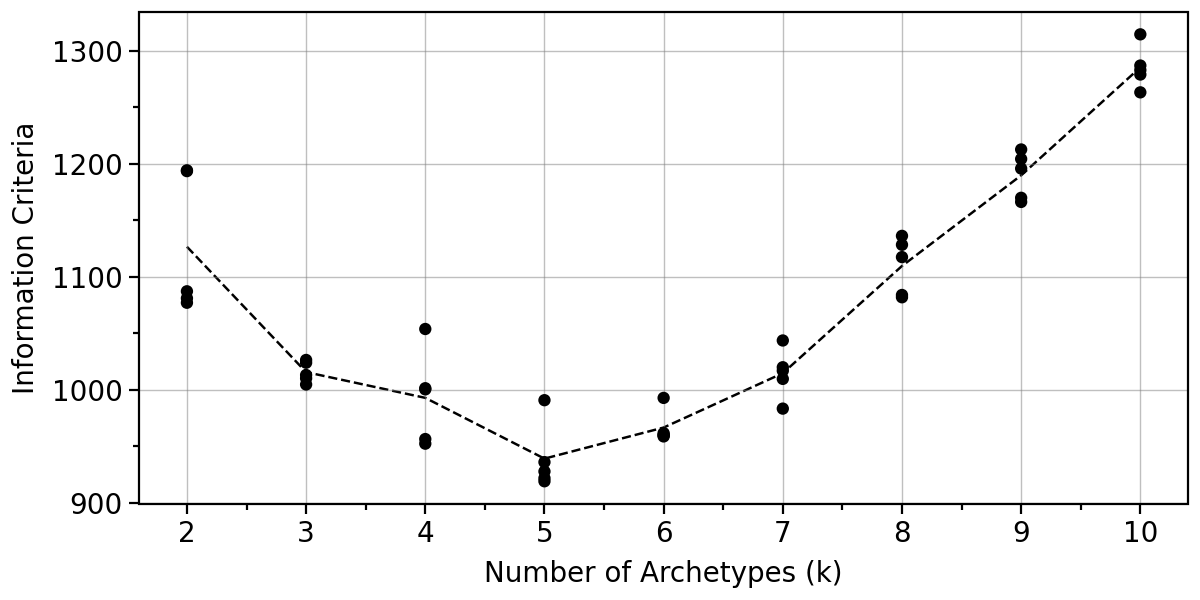

In [4]:
pt.compute_selection_metrics(adata=adata, min_k=2, max_k=10)
pt.plot_var_explained(adata).show()
pt.plot_IC(adata).show()

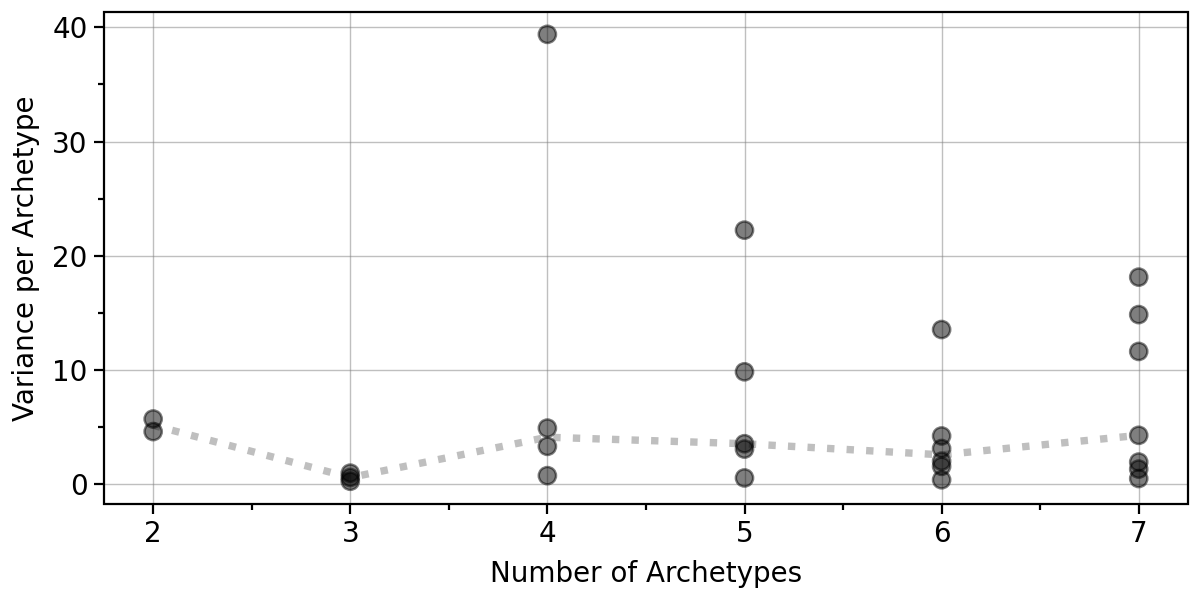

In [5]:
pt.compute_bootstrap_variance(adata, n_bootstrap=30, n_archetypes_list=list(range(2, 8)))
pt.plot_bootstrap_variance(adata)

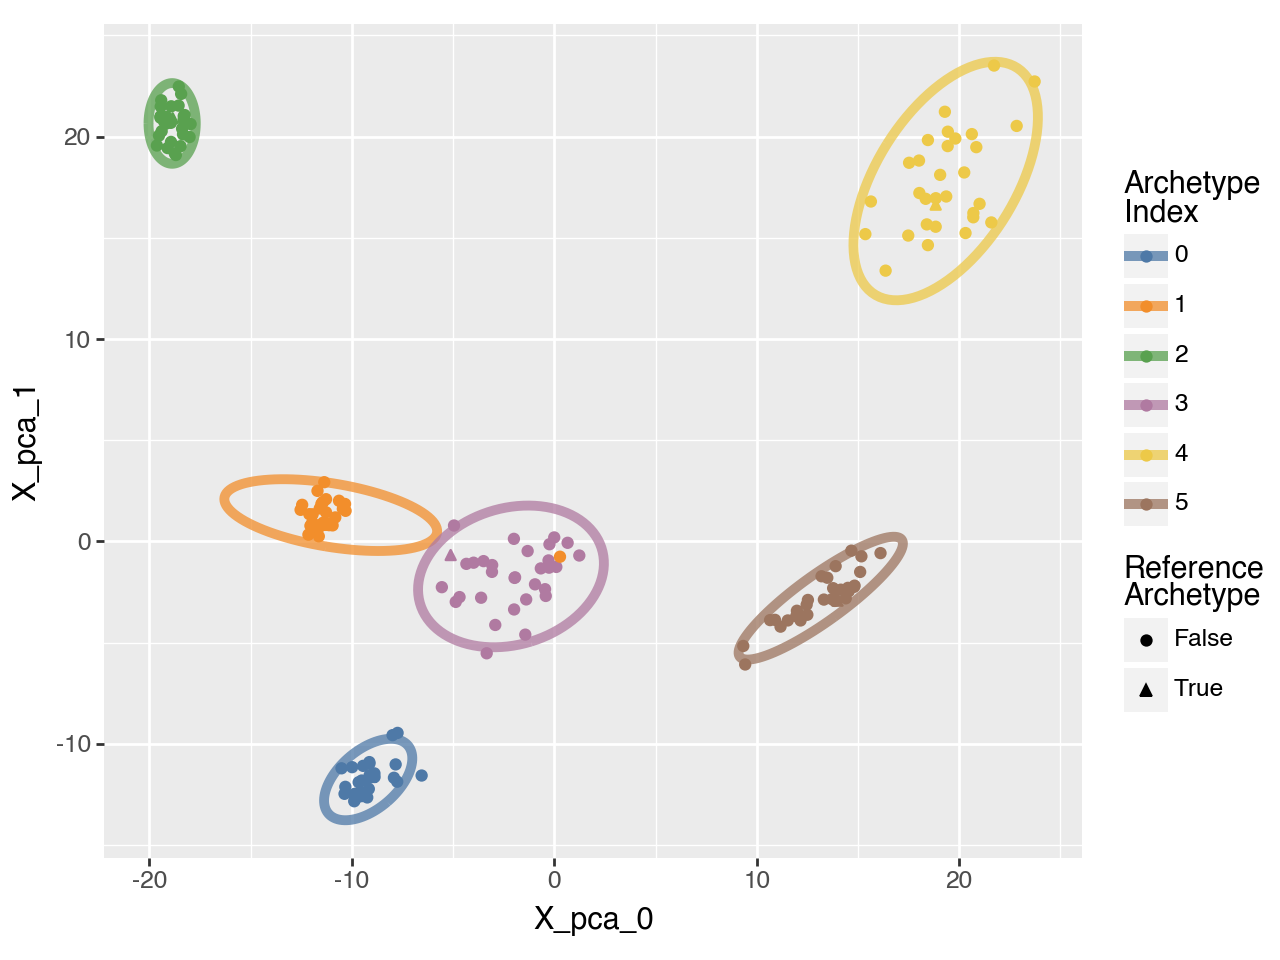

In [6]:
pt.plot_bootstrap_2D(adata, n_archetypes=6)

Here, we will use 5 archetypes. When fitting 4 archetypes we have observed that running archetypal analysis on bootstrapped data shows that one archetype is quite unstable, whereas using 5 worked much better.

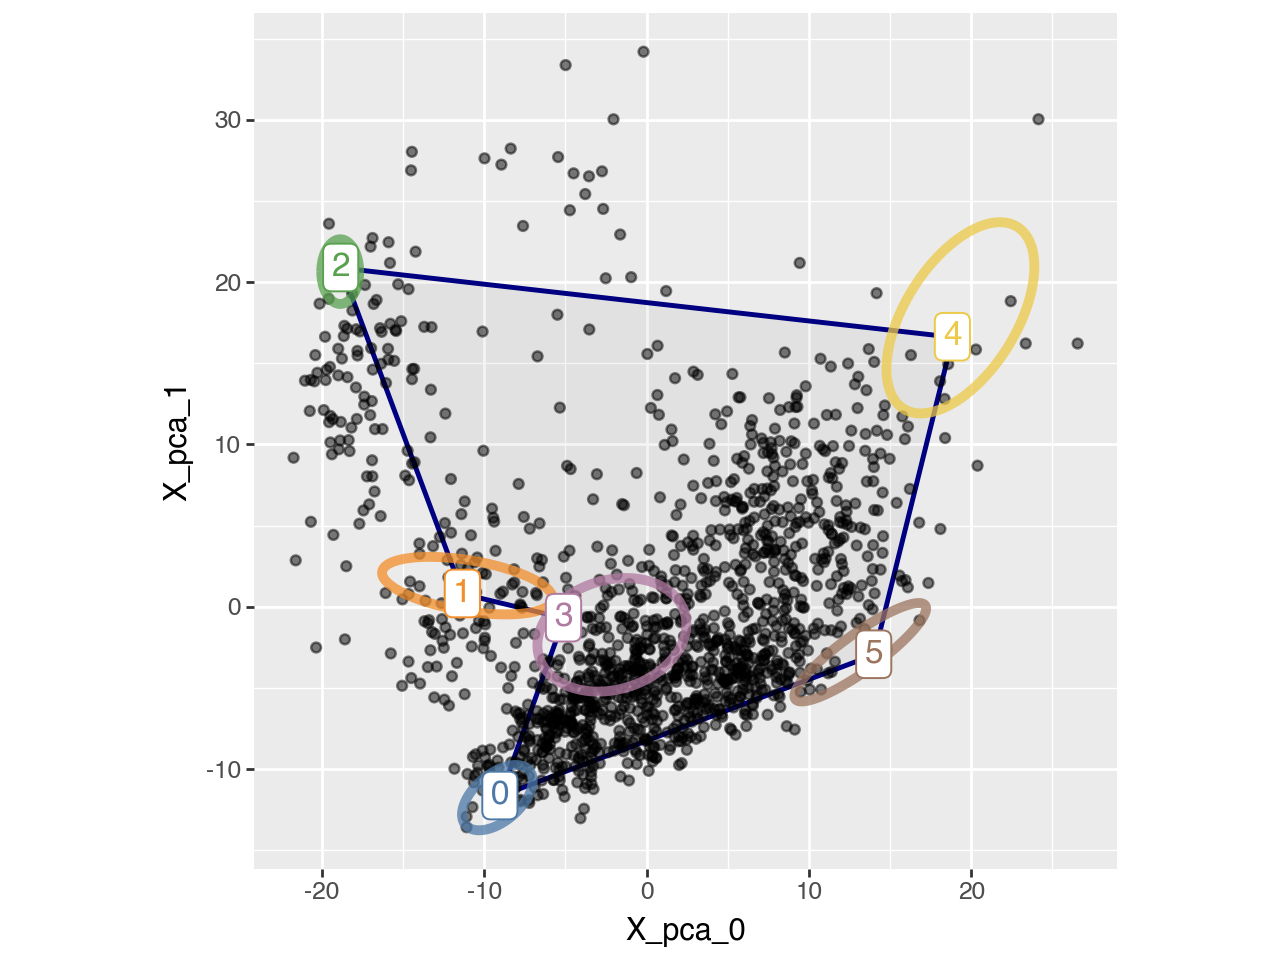

In [7]:
pt.compute_archetypes(adata, n_archetypes=6, verbose=False)
pt.plot_archetypes_2D(adata=adata, show_contours=True)

Determine which genes are characteristic for each archetype

Applied length scale is 12.14.


/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


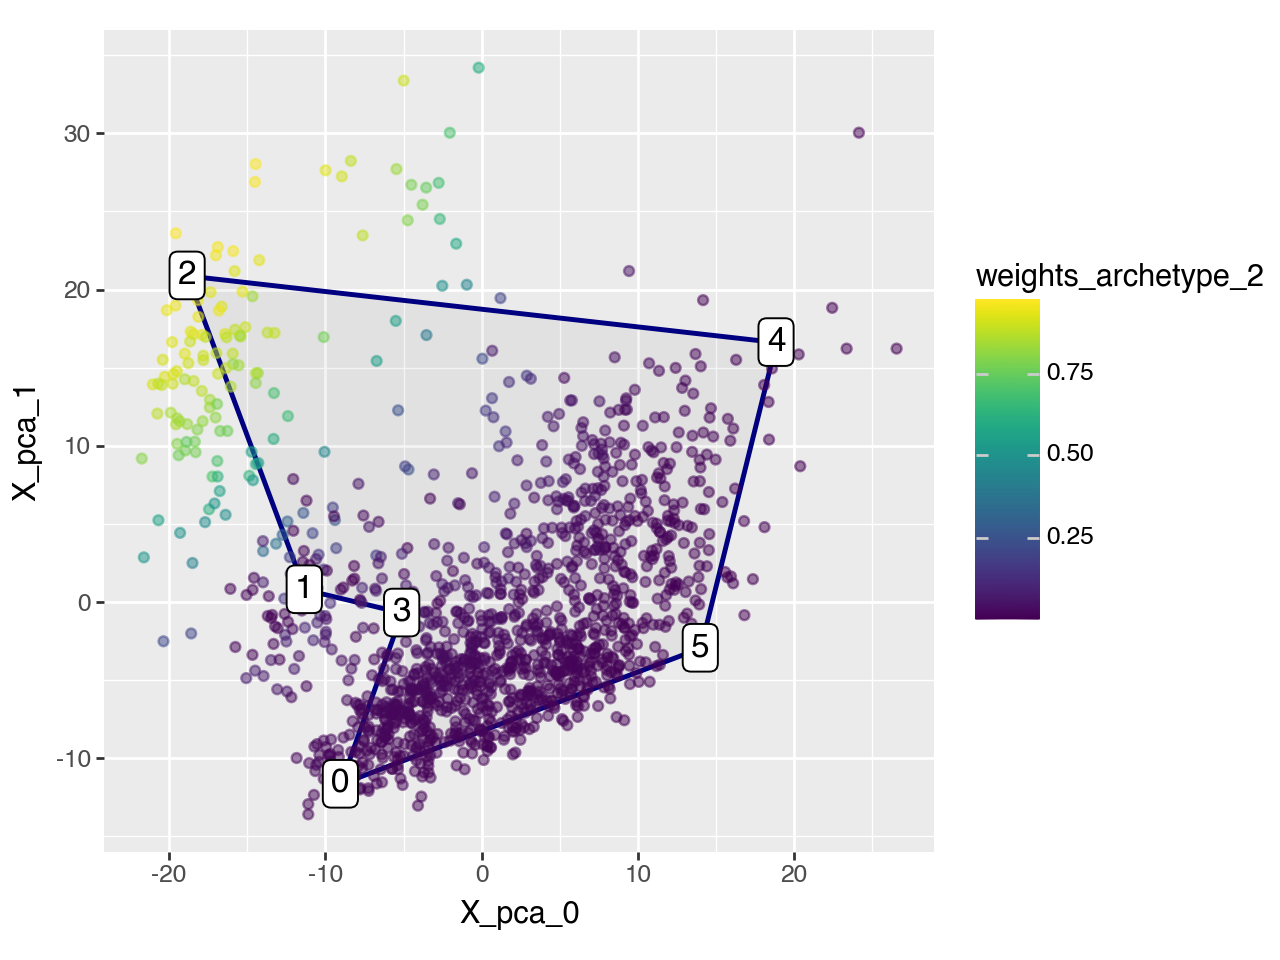

In [8]:
pt.compute_archetype_weights(adata=adata, mode="automatic")
pseudobulk = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

arch_idx = 2
adata.obs[f"weights_archetype_{arch_idx}"] = adata.obsm["cell_weights"][:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}")

In [9]:
specific_genes_per_archetype = get_specific_genes_per_archetype(archetype_expression=pseudobulk, min_score=0.05)

[(arch_id, len(arch_genes)) for arch_id, arch_genes in specific_genes_per_archetype.items()]

[(0, 488), (1, 906), (2, 2045), (3, 1838), (4, 6369), (5, 6098)]

Based on the genes we infer the functions of each archetype

In [10]:
for i in range(len(specific_genes_per_archetype)):
    print(i, specific_genes_per_archetype[i].head(25)["gene"].to_list())

0 ['Serping1', 'Bcl6', 'Selenop', 'C1qtnf3', 'Ms4a4d', 'Gm16559', 'Cxcl12', 'Itm2b', 'Gm15635', 'Mfap4', 'Edil3', 'Rarres2', 'Zfp808', 'Sod3', 'Zmynd15', 'Gm16263', 'Gask1b', 'Sfrp1', 'Hpse2', 'Fbln1', 'C1rb', 'Lrrc61', 'Rax', 'Bhlhe41', 'Serpina3n']
1 ['Lmod1', 'Cnn1', 'Actg2', 'Pdgfc', 'Cdh6', 'Itga8', 'Asb2', 'Myocd', 'Kcnmb1', 'Acta1', 'Trpc6', 'Tnfrsf19', 'Slc2a4', 'Hspb7', 'Myh11', 'Tspan2', 'Gm16000', 'Pde6h', 'Tagln', 'Ctxn1', 'Ptk2b', 'Chrdl2', 'E030013I19Rik', 'Cacna1h', 'Pcp4l1']
2 ['Cd38', '1700071M16Rik', 'Nrg1', 'Lef1', 'Lpar3', 'Trpa1', 'Lef1os1', 'Ptprr', 'Pla2g7', 'Rab3b', 'Lama5', 'Cdhr17', 'Ano2', 'Tbx3', 'Glp2r', 'Cd300e', 'C5ar1', 'Ednrb', 'Sema4d', 'Abcc4', 'Col6a4', 'Paqr5', 'Eva1a', 'Insc', 'Plau']
3 ['Efnb2', 'Gm42721', 'Gm31258', '1700082M22Rik', 'Ugcg', 'Pde1c', 'Gm42785', 'Gm37515', 'Gm4117', 'Gm37954', 'Bmp3', 'Gm42513', 'Gm43577', 'Ryr3', 'Pkib', 'Gm44153', 'Macrod2os1', 'Kcnq1ot1', 'Gm37086', 'Gm37315', 'Mir6240', 'Gm42635', 'Ksr2', 'Ddx17', 'Gm17131']
4 

In [11]:
archetype_functions = {
    0: "ECM-remodeling fibroblasts",
    1: "Vascular-associated fibroblasts",
    2: "Neuronal/epithelial-interacting fibroblasts",
    3: "Myofibroblasts",
    4: "Immune-modulatory fibroblasts"
}

Finally we use [LIANA+](https://liana-py.readthedocs.io/en/latest/) to infer ligand and receptor are enriched between archetypes. But first we need to translate the human ligand-receptor database to mouse gene symbols.

In [12]:
human_resource = li.rs.select_resource('consensus')

# let's say we are interested in zebrafish homologs of human genes
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                   columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})

mouse_resource = li.rs.translate_resource(human_resource,
                                          map_df=map_df,
                                          columns=['ligand', 'receptor'],
                                          replace=True,
                                          # NOTE that we need to define the threshold of redundancies for the mapping
                                          # # in this case, we would keep mappings as long as they don't map to more than 2 mouse genes
                                          # one_to_many=3
                                          )
mouse_resource

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,ligand,receptor
0,Lgals9,Ptprc
1,Lgals9,Met
2,Lgals9,Cd44
3,Lgals9,Lrp1
4,Lgals9,Cd47
...,...,...
4619,Bmp2,Actr2
4620,Bmp15,Actr2
4621,Csf1,Csf3r
4622,Il36g,Ifnar1


In [13]:
archetype_crosstalk = get_archetype_crosstalk(archetype_genes=specific_genes_per_archetype, 
                                              lr_resource=mouse_resource)

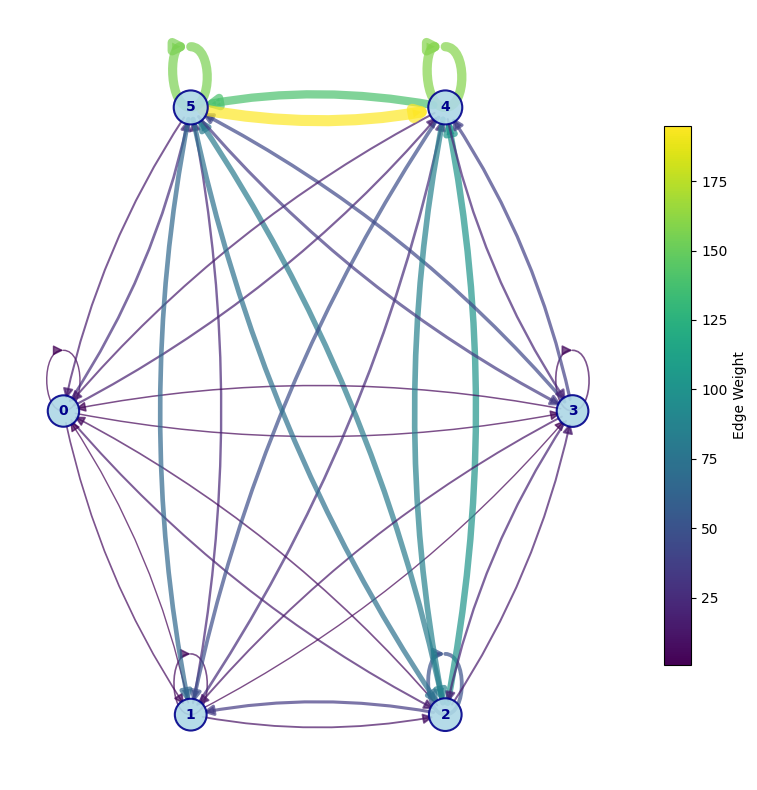

In [14]:
plot_weighted_network(
    specific_genes_per_archetype=specific_genes_per_archetype,
    archetype_crosstalk_dict=archetype_crosstalk,
    layout="shell", 
    seed=42)

## Session Info

In [15]:
import session_info2
print(session_info2.session_info(dependencies=True))

pandas	2.2.3
plotnine	0.14.5
scanpy	1.11.2
liana	1.5.1
partipy	0.0.1
anndata	0.11.4
----	----
sphinxcontrib-serializinghtml	2.0.0
six	1.17.0
asttokens	3.0.0
Pygments	2.19.1
prompt_toolkit	3.0.51
psutil	7.0.0
sphinxcontrib-htmlhelp	2.1.0
mudata	0.3.2
pyparsing	3.2.3
pybiomart	0.2.0
mizani	0.13.5
narwhals	1.41.0
scikit-learn	1.6.1
natsort	8.4.0
importlib_metadata	8.7.0
numpy	2.2.6
PyYAML	6.0.2
certifi	2025.4.26 (2025.04.26)
matplotlib-inline	0.1.7
wrapt	1.17.2
requests	2.32.3
Deprecated	1.2.18
ipykernel	6.29.5
ipython	9.3.0
matplotlib	3.10.3
traitlets	5.14.3
requests-cache	1.2.1
MarkupSafe	3.0.2
sphinxcontrib-qthelp	2.0.0
Jinja2	3.1.6
pytz	2025.2
statsmodels	0.14.4
plotly	6.1.2
h5py	3.13.0
appnope	0.1.4
tornado	6.5.1
urllib3	2.4.0
pyzmq	26.4.0
attrs	25.3.0
defusedxml	0.7.1
stack-data	0.6.3
typing_extensions	4.13.2
scipy	1.15.3
cattrs	25.1.0
cffi	1.17.1
cloudpickle	3.1.1
numba	0.61.2
wcwidth	0.2.13
legacy-api-wrap	1.4.1
session-info2	0.1.2
future	1.0.0
idna	3.10
pure_eval	0.2.3
executing	

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
